# Install

In [0]:
-%pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install "ray[tune]" hyperopt

# Imports

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (average_precision_score, f1_score, log_loss, precision_score, recall_score)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
# Ray Imports
import ray
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch


# Import dataset

In [0]:

FNOL_pdf = pd.read_excel("/Volumes/workspace/default/hastings_direct/Data_Scientist_Interview_FNOL_Data.xlsx")
FNOL_pdf[['Incurred', 'Capped Incurred']] = FNOL_pdf[['Incurred', 'Capped Incurred']].round(0).astype(int)
FNOL_pdf.head()

,Claim Number,date_of_loss,Notifier,Loss_code,Loss_description,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_type_insd_pass_back,TP_type_insd_pass_front,TP_type_driver,TP_type_pass_back,TP_type_pass_front,TP_type_bike,TP_type_cyclist,TP_type_pass_multi,TP_type_pedestrian,TP_type_other,TP_type_nk,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,TP_region_eastang,TP_region_eastmid,TP_region_london,TP_region_north,TP_region_northw,TP_region_outerldn,TP_region_scotland,TP_region_southe,TP_region_southw,TP_region_wales,TP_region_westmid,TP_region_yorkshire,Incurred,Capped Incurred
0,1,2003-04-15,PH,LD003,Head on collision,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,2,2003-04-20,CNF,LD003,Head on collision,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,2801,2801
2,3,2003-04-24,CNF,LD003,Head on collision,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1221,1221
3,4,2003-05-13,CNF,LD003,Head on collision,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3530,3530
4,5,2003-06-11,CNF,LD003,Head on collision,1,48,Other,N/K,N,9,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,3156,3156


In [0]:
row_count, col_count = FNOL_pdf.shape
print(f"Rows: {row_count}, Columns: {col_count}")

Rows: 7691, Columns: 46


# FNOL Data Quality Issues​ 

Found 7 out of 46 columns with data quality issues:

                      Column   Dtype  Unstandardized Placeholders  Negative Anomalies  Unstructured Multi-Labels  Total Issues
0  PH_considered_TP_at_fault  object                         2655                   0                          0          2655
1         Weather_conditions  object                          450                   0                        429           879
2             Vehicle_mobile  object                          442                   0                          0           442
3       Location_of_incident  object                          269                   0                          0           269
4                   Incurred   int64                            0                  47                          0            47
5            Capped Incurred   int64                            0                  47                          0            47
6        Notification_period   int64                      

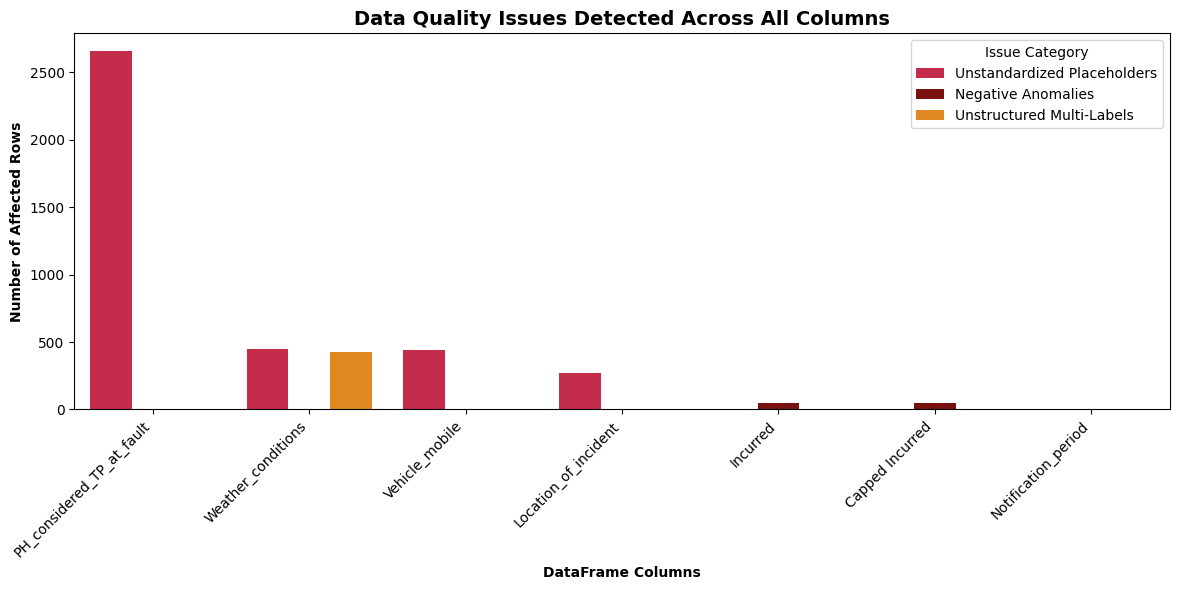

In [0]:



# Define noise placeholders to detect
placeholders = ["n/k", "N/K", "-", "#", "Not Applicable", "N/A", "n/a", "None"]

results = []

for col in FNOL_pdf.columns:
    # 1. Check for unstandardized string placeholders
    col_str = FNOL_pdf[col].astype(str).str.strip()
    placeholder_count = col_str.isin(placeholders).sum()

    # 2. Check for negative numerical anomalies
    numeric_col = pd.to_numeric(FNOL_pdf[col], errors="coerce")
    negative_count = (numeric_col < 0).sum()

    # 3. Check for unstructured multi-label strings (e.g. contains commas)
    comma_count = (
        col_str.str.contains(",", regex=False)
        & ~col_str.isin(placeholders)
        & (col_str != "nan")
    ).sum()

    total_issues = placeholder_count + negative_count + comma_count

    if total_issues > 0:
        results.append(
            {
                "Column": col,
                "Dtype": FNOL_pdf[col].dtype,
                "Unstandardized Placeholders": placeholder_count,
                "Negative Anomalies": negative_count,
                "Unstructured Multi-Labels": comma_count,
                "Total Issues": total_issues,
            }
        )

# Create summary DataFrame
dq_summary = (
    pd.DataFrame(results)
    .sort_values(by="Total Issues", ascending=False)
    .reset_index(drop=True)
)

print(
    f"Found {len(dq_summary)} out of 46 columns with data quality issues:\n"
)
print(dq_summary.to_string())

if not dq_summary.empty:
    plt.figure(figsize=(12, 6))

    # Reshape summary for stacked/grouped bar chart
    plot_data = dq_summary.melt(
        id_vars=["Column"],
        value_vars=[
            "Unstandardized Placeholders",
            "Negative Anomalies",
            "Unstructured Multi-Labels",
        ],
        var_name="Issue Type",
        value_name="Count",
    )

    # Filter out zero counts for cleaner visual
    plot_data = plot_data[plot_data["Count"] > 0]

    sns.barplot(
        data=plot_data,
        x="Column",
        y="Count",
        hue="Issue Type",
        palette=["crimson", "darkred", "darkorange"],
    )

    plt.title(
        "Data Quality Issues Detected Across All Columns",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("DataFrame Columns", fontweight="bold")
    plt.ylabel("Number of Affected Rows", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Issue Category")
    plt.tight_layout()
    plt.show()
else:
    print("No specified data quality issues found in any of the 46 columns.")

In [0]:
FNOL_pdf.describe()

,Claim Number,Notification_period,Inception_to_loss,Time_hour,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_type_insd_pass_back,TP_type_insd_pass_front,TP_type_driver,TP_type_pass_back,TP_type_pass_front,TP_type_bike,TP_type_cyclist,TP_type_pass_multi,TP_type_pedestrian,TP_type_other,TP_type_nk,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,TP_region_eastang,TP_region_eastmid,TP_region_london,TP_region_north,TP_region_northw,TP_region_outerldn,TP_region_scotland,TP_region_southe,TP_region_southw,TP_region_wales,TP_region_westmid,TP_region_yorkshire,Incurred,Capped Incurred
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.0,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.0,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03,7691.000000
mean,3846.000000,7.163438,166.854505,12.729684,0.999220,0.808347,0.232089,0.028995,0.0,0.651671,0.041737,0.058380,0.007281,0.000520,0.0,0.000130,0.075023,0.349369,0.262515,0.073072,0.003641,0.916136,0.595891,0.039397,0.050969,0.021584,0.026915,0.066831,0.036406,0.019893,0.115460,0.090235,0.056560,0.073983,0.079444,9.423263e+03,6106.921077
std,2220.344793,39.138209,104.452906,5.107136,0.027922,0.393627,0.422193,0.219508,0.0,0.544726,0.273589,0.246375,0.088030,0.022801,0.0,0.011403,0.356203,0.523349,0.642956,0.306610,0.064405,0.559457,0.646691,0.241652,0.286229,0.215286,0.201886,0.348440,0.228014,0.187363,0.419528,0.338930,0.311963,0.353122,0.363565,4.985248e+04,11057.280037
min,1.000000,-18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.053900e+04,-10539.000000
25%,1923.500000,0.000000,75.000000,9.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000e+01,25.000000
50%,3846.000000,1.000000,161.000000,13.000000,1.000000,1.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.238000e+03,1238.000000
75%,5768.500000,2.000000,253.000000,17.000000,1.000000,1.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.258500e+03,6258.500000
max,7691.000000,1042.000000,365.000000,23.000000,1.000000,1.000000,1.000000,4.000000,0.0,5.000000,6.000000,2.000000,2.000000,1.000000,0.0,1.000000,6.000000,6.000000,7.000000,4.000000,2.000000,7.000000,6.000000,5.000000,6.000000,9.000000,4.000000,7.000000,5.000000,6.000000,9.000000,5.000000,7.000000,6.000000,5.000000,1.951894e+06,50000.000000


In [0]:
cols = ['Claim Number', 'date_of_loss', 'Notifier', 'Loss_code', 'Loss_description', 'Notification_period', 'Inception_to_loss', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile', 'Time_hour', 'Main_driver', 'PH_considered_TP_at_fault', 'Vechile_registration_present', 'Incident_details_present', 'Injury_details_present', 'TP_type_insd_pass_back', 'TP_type_insd_pass_front', 'TP_type_driver', 'TP_type_pass_back', 'TP_type_pass_front', 'TP_type_bike', 'TP_type_cyclist', 'TP_type_pass_multi', 'TP_type_pedestrian', 'TP_type_other', 'TP_type_nk', 'TP_injury_whiplash', 'TP_injury_traumatic', 'TP_injury_fatality', 'TP_injury_unclear', 'TP_injury_nk', 'TP_region_eastang', 'TP_region_eastmid', 'TP_region_london', 'TP_region_north', 'TP_region_northw', 'TP_region_outerldn', 'TP_region_scotland', 'TP_region_southe', 'TP_region_southw', 'TP_region_wales', 'TP_region_westmid', 'TP_region_yorkshire', 'Incurred', 'Capped Incurred']

# Print unique values for each column
for col in cols:
    print(f"=== {col} ===")
    print(FNOL_pdf[col].unique())
    print()

=== Claim Number ===
[   1    2    3 ... 7689 7690 7691]

=== date_of_loss ===
['2003-04-15' '2003-04-20' '2003-04-24' ... '2015-06-28' '2015-06-29'
 '2015-06-30']

=== Notifier ===
['PH' 'CNF' 'Other' 'TP' 'NamedDriver']

=== Loss_code ===
['LD003']

=== Loss_description ===
['Head on collision']

=== Notification_period ===
[  22    1    5   16    0    4    2    6   61   20    3   10   48  145
    8   39    7   14   23  452   81   25   11   21   13   17  132   42
   63   73   47  181   12   15    9   19   27   31   55   18  252   26
   44  187   24   69   89  122  124   33   91   67   53  159  109  126
   29   34   62   94   54   38  377  113   36  118  211   83   28  111
   52   74   64  439   37   46  146   32  129  108   87   78  154   30
   75  315  390  173  259  577  961   85  169   49  165   72   71  279
   92 1042  366  365  134  720  117   40  510  171   65  519  103   50
   43  110  297   56  114   86  235  222  239  141  130  229  170  180
  137  248  381  336  201   57  1

# Data Cleansing & Features engineering​

## Drop 5 Zero variance & Unhelpful  features:​

In [0]:
FNOL_pdf = FNOL_pdf.drop(columns=["Claim Number","Loss_code", "Loss_description", "TP_type_insd_pass_front", 'TP_type_pass_multi'])

row_count, col_count = FNOL_pdf.shape
print(f"Rows: {row_count}, Columns: {col_count}")

Rows: 7691, Columns: 41


## Regions

In [0]:
region_cols = [
    'TP_region_eastang', 'TP_region_eastmid', 'TP_region_london', 
    'TP_region_north', 'TP_region_northw', 'TP_region_outerldn', 
    'TP_region_scotland', 'TP_region_southe', 'TP_region_southw', 
    'TP_region_wales', 'TP_region_westmid', 'TP_region_yorkshire'
]

# 1. Clean all regional columns and convert string placeholders to clean integers
for col in region_cols:
    FNOL_pdf[col] = pd.to_numeric(FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), errors='coerce'
    ).fillna(0).astype(int)

# 2. Total third-party headcount aggregated across all regions
FNOL_pdf['Total_Regional_TP_Count'] = FNOL_pdf[region_cols].sum(axis=1)

# 3. Define tie-aware primary region extraction logic
def get_primary_region(row):
    # Filter active regions with headcounts > 0
    active_regions = row[region_cols][row[region_cols] > 0]
    
    if active_regions.empty:
        return 'None_Recorded'
    
    max_val = active_regions.max()
    top_regions = active_regions[active_regions == max_val].index.tolist()
    
    # If a single region clearly leads in headcount
    if len(top_regions) == 1:
        return top_regions[0].replace('TP_region_', '')
    
    # If there is a headcount tie between two or more top regions
    return 'Multi_Region_Tie'

# 4. Apply the tie-aware function row-by-row
FNOL_pdf['Primary_TP_Region'] = FNOL_pdf.apply(get_primary_region, axis=1)
FNOL_pdf.head(50)

,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_type_insd_pass_back,TP_type_driver,TP_type_pass_back,TP_type_pass_front,TP_type_bike,TP_type_cyclist,TP_type_pedestrian,TP_type_other,TP_type_nk,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,TP_region_eastang,TP_region_eastmid,TP_region_london,TP_region_north,TP_region_northw,TP_region_outerldn,TP_region_scotland,TP_region_southe,TP_region_southw,TP_region_wales,TP_region_westmid,TP_region_yorkshire,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,northw
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,2801,2801,1,southe
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1221,1221,1,northw
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3530,3530,1,westmid
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,3156,3156,0,None_Recorded
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,10502,10502,0,None_Recorded
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,91,91,1,north
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,9130,9130,1,wales
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,81,81,0,None_Recorded
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,447,447,1,north


In [0]:

FNOL_pdf = FNOL_pdf.drop(columns=region_cols)
FNOL_pdf.head(10)

,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_type_insd_pass_back,TP_type_driver,TP_type_pass_back,TP_type_pass_front,TP_type_bike,TP_type_cyclist,TP_type_pedestrian,TP_type_other,TP_type_nk,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,northw
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,2801,2801,1,southe
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1221,1221,1,northw
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,3530,3530,1,westmid
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,3156,3156,0,None_Recorded
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,2,10502,10502,0,None_Recorded
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,91,91,1,north
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,9130,9130,1,wales
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,81,81,0,None_Recorded
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,447,447,1,north


## Third party type

In [0]:
# List of all 9 third-party type features
all_tp_type_cols = [
    'TP_type_insd_pass_back', 'TP_type_driver', 'TP_type_pass_back', 
    'TP_type_pass_front', 'TP_type_bike', 'TP_type_cyclist', 
    'TP_type_pedestrian', 'TP_type_other', 'TP_type_nk'
]

# 1. Clean all 9 columns (convert placeholders '-', 'n/k', '#' to 0)
for col in all_tp_type_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = pd.to_numeric(
            FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), 
            errors='coerce'
        ).fillna(0).astype(int)

# 2. Feature 1: Total Passenger Count (Front + Back Passengers)
FNOL_pdf['Total_TP_Passenger_Count'] = (
    FNOL_pdf['TP_type_pass_front'] + FNOL_pdf['TP_type_pass_back'] + FNOL_pdf['TP_type_insd_pass_back']
)

# 3. Feature 2: Vulnerable Road User Flag (Bikes, Cyclists, Pedestrians)
FNOL_pdf['Has_Vulnerable_Road_User'] = (
    (FNOL_pdf['TP_type_bike'] > 0) | 
    (FNOL_pdf['TP_type_cyclist'] > 0) | 
    (FNOL_pdf['TP_type_pedestrian'] > 0)
).astype(int)

# 4. Feature 3: Overall TP Count (Includes ALL 9 columns, including TP_type_nk)
existing_cols = [c for c in all_tp_type_cols if c in FNOL_pdf.columns]
FNOL_pdf['Total_TP_Type_Count'] = FNOL_pdf[existing_cols].sum(axis=1)
FNOL_pdf.head(50)



,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_type_insd_pass_back,TP_type_driver,TP_type_pass_back,TP_type_pass_front,TP_type_bike,TP_type_cyclist,TP_type_pedestrian,TP_type_other,TP_type_nk,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,northw,0,0,1
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,2801,2801,1,southe,0,0,1
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1221,1221,1,northw,0,0,1
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,3530,3530,1,westmid,0,0,1
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,3156,3156,0,None_Recorded,0,0,1
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,2,10502,10502,0,None_Recorded,0,0,1
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,91,91,1,north,0,0,1
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,9130,9130,1,wales,0,0,1
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,81,81,0,None_Recorded,0,0,1
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,447,447,1,north,0,0,1


In [0]:
FNOL_pdf = FNOL_pdf.drop(columns=all_tp_type_cols)
FNOL_pdf.head(10)


,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,0,1,0,0,0,1,northw,0,0,1
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,0,0,0,1,0,2801,2801,1,southe,0,0,1
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,0,0,0,1,0,1221,1221,1,northw,0,0,1
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,0,0,0,1,0,3530,3530,1,westmid,0,0,1
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,0,0,0,1,1,3156,3156,0,None_Recorded,0,0,1
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,0,0,1,1,2,10502,10502,0,None_Recorded,0,0,1
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,0,0,0,1,0,91,91,1,north,0,0,1
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,0,0,0,1,0,9130,9130,1,wales,0,0,1
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,0,0,0,1,1,81,81,0,None_Recorded,0,0,1
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,0,0,0,1,0,447,447,1,north,0,0,1


## Third party injury

In [0]:
# List of the 5 raw TP injury columns
injury_cols = ['TP_injury_whiplash', 'TP_injury_traumatic', 'TP_injury_fatality', 'TP_injury_unclear', 'TP_injury_nk']

# 1. Clean missing placeholders ('-', 'n/k', '#') across all 5 columns
for col in injury_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = pd.to_numeric(
            FNOL_pdf[col].astype(str).replace(['-', 'n/k', '#', 'nan', 'None', ''], '0'), 
            errors='coerce'
        ).fillna(0).astype(int)

# 2. Define the hierarchical severity function
def determine_max_injury_tier(row):
    # Tier 4: Fatality (Highest priority)
    if row.get('TP_injury_fatality', 0) > 0:
        return 4
    # Tier 3: Traumatic / Severe Body Injury
    elif row.get('TP_injury_traumatic', 0) > 0:
        return 3
    # Tier 2: Whiplash / Soft Tissue Injury
    elif row.get('TP_injury_whiplash', 0) > 0:
        return 2
    # Tier 1: Unclear or Not Known Injury details reported
    elif row.get('TP_injury_unclear', 0) > 0 or row.get('TP_injury_nk', 0) > 0:
        return 1
    # Tier 0: No Injury Recorded
    else:
        return 0

# 3. Apply the hierarchy row-by-row
FNOL_pdf['Max_Injury_Severity_Tier'] = FNOL_pdf.apply(determine_max_injury_tier, axis=1)

# 4. Optional: Also capture total count of injured third parties
FNOL_pdf['Total_Injured_TP_Count'] = FNOL_pdf[injury_cols].sum(axis=1)
FNOL_pdf.head(50)


,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,TP_injury_whiplash,TP_injury_traumatic,TP_injury_fatality,TP_injury_unclear,TP_injury_nk,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,0,1,0,0,0,1,northw,0,0,1,1,1
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,0,0,0,1,0,2801,2801,1,southe,0,0,1,1,1
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,0,0,0,1,0,1221,1221,1,northw,0,0,1,1,1
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,0,0,0,1,0,3530,3530,1,westmid,0,0,1,1,1
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,0,0,0,1,1,3156,3156,0,None_Recorded,0,0,1,1,2
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,0,0,1,1,2,10502,10502,0,None_Recorded,0,0,1,4,4
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,0,0,0,1,0,91,91,1,north,0,0,1,1,1
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,0,0,0,1,0,9130,9130,1,wales,0,0,1,1,1
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,0,0,0,1,1,81,81,0,None_Recorded,0,0,1,1,2
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,0,0,0,1,0,447,447,1,north,0,0,1,1,1


In [0]:
FNOL_pdf = FNOL_pdf.drop(columns=injury_cols)
FNOL_pdf.head(10)

,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,1,northw,0,0,1,1,1
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,2801,2801,1,southe,0,0,1,1,1
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,1221,1221,1,northw,0,0,1,1,1
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,3530,3530,1,westmid,0,0,1,1,1
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,3156,3156,0,None_Recorded,0,0,1,1,2
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,10502,10502,0,None_Recorded,0,0,1,4,4
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,91,91,1,north,0,0,1,1,1
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,9130,9130,1,wales,0,0,1,1,1
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,81,81,0,None_Recorded,0,0,1,1,2
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,447,447,1,north,0,0,1,1,1


## date of loss

In [0]:
# 1. Identify your date column (replace 'date_of_loss' with your exact column name if different)
date_col = 'date_of_loss'

# 2. Convert to Pandas datetime format (handles formats like 'YYYY-MM-DD', 'DD/MM/YYYY', etc.)
FNOL_pdf[date_col] = pd.to_datetime(FNOL_pdf[date_col], errors='coerce')

# 3. Extract cyclical and temporal components
FNOL_pdf['loss_year'] = FNOL_pdf[date_col].dt.year
FNOL_pdf['loss_month'] = FNOL_pdf[date_col].dt.month
FNOL_pdf['loss_day_of_week'] = FNOL_pdf[date_col].dt.day_name()
FNOL_pdf.head(10)

,date_of_loss,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count,loss_year,loss_month,loss_day_of_week
0,2003-04-15,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,1,northw,0,0,1,1,1,2003,4,Tuesday
1,2003-04-20,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,2801,2801,1,southe,0,0,1,1,1,2003,4,Sunday
2,2003-04-24,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,1221,1221,1,northw,0,0,1,1,1,2003,4,Thursday
3,2003-05-13,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,3530,3530,1,westmid,0,0,1,1,1,2003,5,Tuesday
4,2003-06-11,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,3156,3156,0,None_Recorded,0,0,1,1,2,2003,6,Wednesday
5,2003-06-24,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,10502,10502,0,None_Recorded,0,0,1,4,4,2003,6,Tuesday
6,2003-07-16,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,91,91,1,north,0,0,1,1,1,2003,7,Wednesday
7,2003-07-17,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,9130,9130,1,wales,0,0,1,1,1,2003,7,Thursday
8,2003-07-20,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,81,81,0,None_Recorded,0,0,1,1,2,2003,7,Sunday
9,2003-07-29,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,447,447,1,north,0,0,1,1,1,2003,7,Tuesday


In [0]:
FNOL_pdf = FNOL_pdf.drop(columns=date_col)
FNOL_pdf.head(10)

,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Incurred,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count,loss_year,loss_month,loss_day_of_week
0,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,0,1,northw,0,0,1,1,1,2003,4,Tuesday
1,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,2801,2801,1,southe,0,0,1,1,1,2003,4,Sunday
2,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,1221,1221,1,northw,0,0,1,1,1,2003,4,Thursday
3,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,3530,3530,1,westmid,0,0,1,1,1,2003,5,Tuesday
4,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,3156,3156,0,None_Recorded,0,0,1,1,2,2003,6,Wednesday
5,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,10502,10502,0,None_Recorded,0,0,1,4,4,2003,6,Tuesday
6,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,91,91,1,north,0,0,1,1,1,2003,7,Wednesday
7,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,9130,9130,1,wales,0,0,1,1,1,2003,7,Thursday
8,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,81,81,0,None_Recorded,0,0,1,1,2,2003,7,Sunday
9,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,447,447,1,north,0,0,1,1,1,2003,7,Tuesday


## Drop Incurred column​

In [0]:
FNOL_pdf = FNOL_pdf.drop(columns="Incurred")
FNOL_pdf.head(10)

,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count,loss_year,loss_month,loss_day_of_week
0,PH,22,13,Main Road,NORMAL,Y,10,Other,n/k,1,0,0,0,1,northw,0,0,1,1,1,2003,4,Tuesday
1,CNF,1,9,Main Road,WET,Y,18,Other,n/k,1,1,0,2801,1,southe,0,0,1,1,1,2003,4,Sunday
2,CNF,5,17,Main Road,WET,Y,16,Y,n/k,1,0,0,1221,1,northw,0,0,1,1,1,2003,4,Thursday
3,CNF,1,23,Main Road,N/K,Y,14,Other,n/k,1,1,0,3530,1,westmid,0,0,1,1,1,2003,5,Tuesday
4,CNF,1,48,Other,N/K,N,9,Other,n/k,1,1,0,3156,0,None_Recorded,0,0,1,1,2,2003,6,Wednesday
5,PH,16,23,Other,N/K,N,0,Other,n/k,1,1,0,10502,0,None_Recorded,0,0,1,4,4,2003,6,Tuesday
6,Other,5,4,Main Road,NORMAL,N,18,Other,n/k,1,0,0,91,1,north,0,0,1,1,1,2003,7,Wednesday
7,Other,0,40,Main Road,WET,Y,7,Other,n/k,1,1,0,9130,1,wales,0,0,1,1,1,2003,7,Thursday
8,PH,4,26,Minor Road,WET,Y,22,Other,n/k,1,0,1,81,0,None_Recorded,0,0,1,1,2,2003,7,Sunday
9,CNF,2,85,Main Road,N/K,N,22,Other,n/k,1,0,1,447,1,north,0,0,1,1,1,2003,7,Tuesday


In [0]:
cols = ['Notifier', 'Notification_period', 'Inception_to_loss', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile', 'Time_hour', 'Main_driver', 'PH_considered_TP_at_fault', 'Vechile_registration_present', 'Incident_details_present', 'Injury_details_present', 'Capped Incurred', 'Total_Regional_TP_Count', 'Primary_TP_Region', 'Total_TP_Passenger_Count', 'Has_Vulnerable_Road_User', 'Total_TP_Type_Count', 'Max_Injury_Severity_Tier', 'Total_Injured_TP_Count', 'loss_year', 'loss_month', 'loss_day_of_week']

# Print unique values for each column
for col in cols:
    print(f"=== {col} ===")
    print(FNOL_pdf[col].unique())
    print()

=== Notifier ===
['PH' 'CNF' 'Other' 'TP' 'NamedDriver']

=== Notification_period ===
[  22    1    5   16    0    4    2    6   61   20    3   10   48  145
    8   39    7   14   23  452   81   25   11   21   13   17  132   42
   63   73   47  181   12   15    9   19   27   31   55   18  252   26
   44  187   24   69   89  122  124   33   91   67   53  159  109  126
   29   34   62   94   54   38  377  113   36  118  211   83   28  111
   52   74   64  439   37   46  146   32  129  108   87   78  154   30
   75  315  390  173  259  577  961   85  169   49  165   72   71  279
   92 1042  366  365  134  720  117   40  510  171   65  519  103   50
   43  110  297   56  114   86  235  222  239  141  130  229  170  180
  137  248  381  336  201   57  101  128  925  121  253  156  856   59
  370   41  496  104  367  320  188  168  127  741   84  140   93  102
  308  106  546  196  376  339  149  394   80   45   35  294   -1   68
  306   79  -18  100   76   60   98   77  162   -2   88  123  

In [0]:
import numpy as np

# 1. Define your 10 categorical columns
cat_cols = [
    'Notifier', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile', 'Main_driver', 
    'PH_considered_TP_at_fault', 'Primary_TP_Region', 'loss_day_of_week'
]

# 2. Define missing value placeholders and casing standardizations
missing_placeholders = ['N/K', 'n/k', 'NK', 'nk', '-', '#', 'n/a', 'N/A', 'None', 'nan', '', 'Not Applicable']
casing_fixes = {'other': 'OTHER', 'Other': 'OTHER', 'unknown': 'UNKNOWN', 'Unknown': 'UNKNOWN'}

# 3. Process all 10 columns in a single loop
for col in cat_cols:
    if col in FNOL_pdf.columns:
        FNOL_pdf[col] = (
            FNOL_pdf[col]
            .astype(str)                           # Ensure string type for reliable replacement
            .str.strip()                           # Strip leading/trailing whitespace
            .replace(missing_placeholders, np.nan) # Map unknown placeholders to true NaN
            .replace(casing_fixes)                # Standardize 'Other' casing
            .astype('category')                    # Convert to category for XGBoost
        )

In [0]:
# Notification Period = Notification Date - Incident Date- can not be negative
FNOL_pdf = FNOL_pdf[(FNOL_pdf['Notification_period'] >= 0) & (FNOL_pdf['Capped Incurred'] >= 0)]

In [0]:
cols = ['Notifier', 'Notification_period', 'Inception_to_loss', 'Location_of_incident', 'Weather_conditions', 'Vehicle_mobile', 'Time_hour', 'Main_driver', 'PH_considered_TP_at_fault', 'Vechile_registration_present', 'Incident_details_present', 'Injury_details_present', 'Capped Incurred', 'Total_Regional_TP_Count', 'Primary_TP_Region', 'Total_TP_Passenger_Count', 'Has_Vulnerable_Road_User', 'Total_TP_Type_Count', 'Max_Injury_Severity_Tier', 'Total_Injured_TP_Count', 'loss_year', 'loss_month', 'loss_day_of_week']

# Print unique values for each column
for col in cols:
    print(f"=== {col} ===")
    print(FNOL_pdf[col].unique())
    print()

=== Notifier ===
['PH', 'CNF', 'OTHER', 'TP', 'NamedDriver']
Categories (5, object): ['CNF', 'NamedDriver', 'OTHER', 'PH', 'TP']

=== Notification_period ===
[  22    1    5   16    0    4    2    6   61   20    3   10   48  145
    8   39    7   14   23  452   81   25   11   21   13   17  132   42
   63   73   47  181   12   15    9   19   27   31   55   18  252   26
   44  187   24   69   89  122  124   33   91   67   53  159  109  126
   29   34   62   94   54   38  377  113   36  118  211   83   28  111
   52   74   64  439   37   46  146   32  129  108   87   78  154   30
   75  315  390  173  259  577  961   85  169   49  165   72   71  279
   92 1042  366  365  134  720  117   40  510  171   65  519  103   50
   43  110  297   56  114   86  235  222  239  141  130  229  170  180
  137  248  381  336  201   57  101  128  925  121  253  156  856   59
  370   41  496  104  367  320  188  168  127  741   84  140   93  102
  308  106  546  196  376  339  149  394   80   45   35  294 

In [0]:
FNOL_pdf.head()

,Notifier,Notification_period,Inception_to_loss,Location_of_incident,Weather_conditions,Vehicle_mobile,Time_hour,Main_driver,PH_considered_TP_at_fault,Vechile_registration_present,Incident_details_present,Injury_details_present,Capped Incurred,Total_Regional_TP_Count,Primary_TP_Region,Total_TP_Passenger_Count,Has_Vulnerable_Road_User,Total_TP_Type_Count,Max_Injury_Severity_Tier,Total_Injured_TP_Count,loss_year,loss_month,loss_day_of_week
0,PH,22,13,Main Road,NORMAL,Y,10,OTHER,NaN,1,0,0,0,1,northw,0,0,1,1,1,2003,4,Tuesday
1,CNF,1,9,Main Road,WET,Y,18,OTHER,NaN,1,1,0,2801,1,southe,0,0,1,1,1,2003,4,Sunday
2,CNF,5,17,Main Road,WET,Y,16,Y,NaN,1,0,0,1221,1,northw,0,0,1,1,1,2003,4,Thursday
3,CNF,1,23,Main Road,NaN,Y,14,OTHER,NaN,1,1,0,3530,1,westmid,0,0,1,1,1,2003,5,Tuesday
4,CNF,1,48,OTHER,NaN,N,9,OTHER,NaN,1,1,0,3156,0,None_Recorded,0,0,1,1,2,2003,6,Wednesday


/home/spark-97bae7fa-eb42-48c4-bf8b-89/.ipykernel/75/command-4735001931856357-1060242631:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


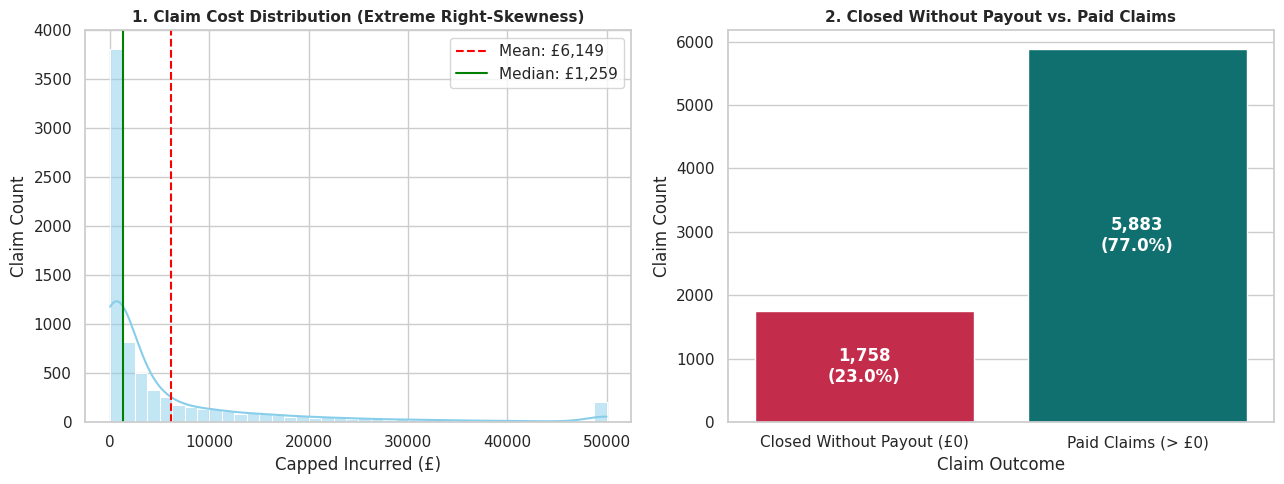

In [0]:
sns.set_theme(style="whitegrid")
# Reduced to 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------------------------------------------------------
# Plot 1: Extreme Right-Skewness & Cap Accumulation
# -------------------------------------------------------------------------
sns.histplot(
    data=FNOL_pdf,
    x="Capped Incurred",
    bins=40,
    kde=True,
    color="skyblue",
    ax=axes[0],
)
axes[0].set_title(
    "1. Claim Cost Distribution (Extreme Right-Skewness)",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_xlabel("Capped Incurred (£)")
axes[0].set_ylabel("Claim Count")

# Annotate median vs mean to highlight skewness
mean_val = FNOL_pdf["Capped Incurred"].mean()
median_val = FNOL_pdf["Capped Incurred"].median()
axes[0].axvline(
    mean_val, color="red", linestyle="--", label=f"Mean: £{mean_val:,.0f}"
)
axes[0].axvline(
    median_val, color="green", linestyle="-", label=f"Median: £{median_val:,.0f}"
)
axes[0].legend()

# -------------------------------------------------------------------------
# Plot 2: Mass Zero Spike (Zero Inflation)
# -------------------------------------------------------------------------
# Classify claims as Zero (£0) vs Positive (> £0)
zero_count = (FNOL_pdf["Capped Incurred"] == 0).sum()
pos_count = (FNOL_pdf["Capped Incurred"] > 0).sum()

zero_df = pd.DataFrame(
    {
        "Claim Outcome": ["Closed Without Payout (£0)", "Paid Claims (> £0)"],
        "Count": [zero_count, pos_count],
    }
)

sns.barplot(
    data=zero_df,
    x="Claim Outcome",
    y="Count",
    palette=["crimson", "teal"],
    ax=axes[1],
)
axes[1].set_title(
    "2. Closed Without Payout vs. Paid Claims",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_ylabel("Claim Count")

for p in axes[1].patches:
    pct = (p.get_height() / len(FNOL_pdf)) * 100
    axes[1].annotate(
        f"{int(p.get_height()):,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()